In [1]:
#STEP-1
#Environment setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
print(tf.__version__)

2.20.0


In [3]:
from tensorflow.keras.datasets import cifar10

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset loaded successfully


In [4]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [5]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


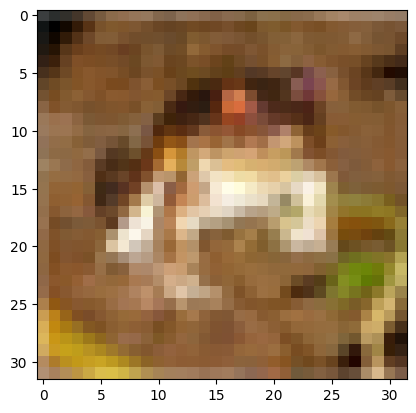

In [6]:
plt.imshow(x_train[0])
plt.show()

In [7]:
print(y_train[0])
print(class_names[6])

[6]
frog


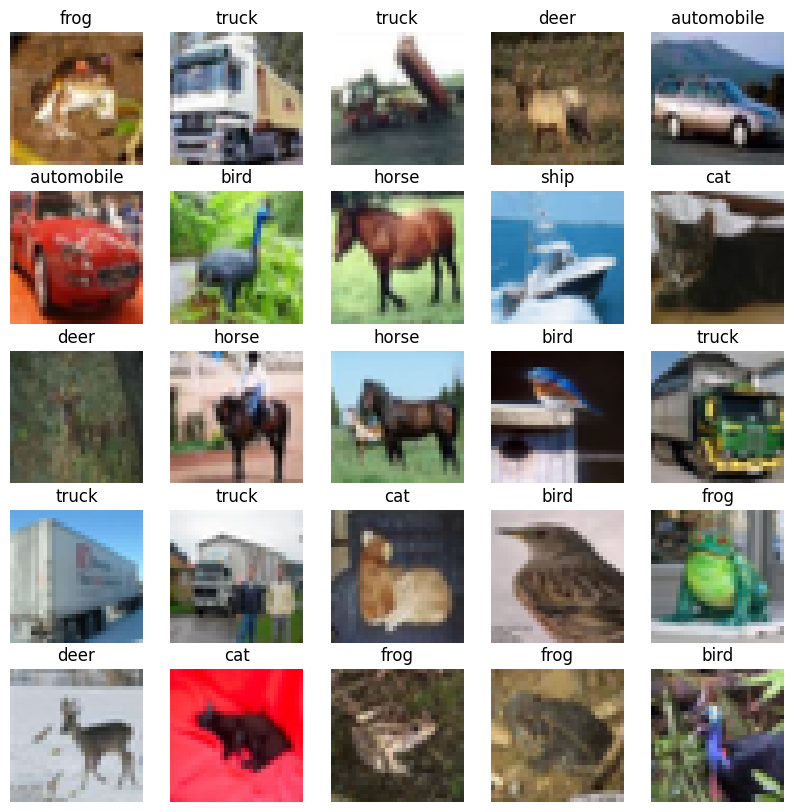

In [8]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [9]:
print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:
#STEP-2
#importing CNN Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

In [12]:
#creating CNN Model
model = Sequential([

    # First Convolution Layer
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),

    # First Pooling Layer
    MaxPooling2D((2,2)),

    # Second Convolution Layer
    Conv2D(64, (3,3), activation='relu'),

    # Second Pooling Layer
    MaxPooling2D((2,2)),

    # Convert to 1D
    Flatten(),

    # Dense Layer
    Dense(64, activation='relu'),

    # Output Layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#compiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
#Training the CNN
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.4807 - loss: 1.4547 - val_accuracy: 0.5845 - val_loss: 1.1978
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6124 - loss: 1.1102 - val_accuracy: 0.6260 - val_loss: 1.0817
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6582 - loss: 0.9853 - val_accuracy: 0.6478 - val_loss: 1.0072
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6886 - loss: 0.9070 - val_accuracy: 0.6809 - val_loss: 0.9319
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 65s 42ms/step - accuracy: 0.7090 - loss: 0.8380 - val_accuracy: 0.6820 - val_loss: 0.9386
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7255 - loss: 0.7887 - val_accuracy: 0.6889 - val_loss: 0.9211
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7441 - loss: 0.7398 - val_accuracy: 0.6948 - val_loss: 0.8942
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7544 -

In [16]:
#evaluating the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7081 - loss: 0.9073
Test Accuracy: 0.7081000208854675


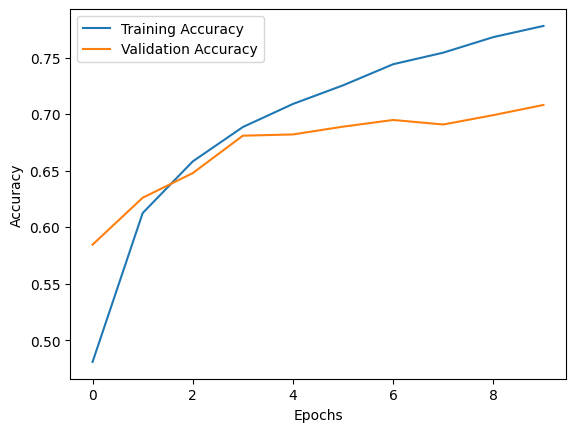

In [17]:
#visualizing training performance
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

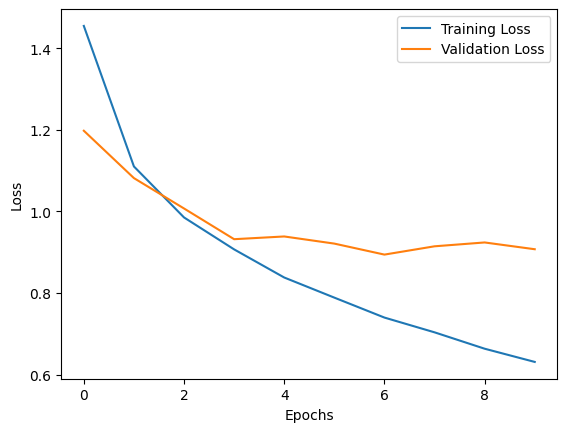

In [18]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [19]:
prediction = model.predict(x_test)
print(prediction[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
[2.1582242e-04 3.3918663e-05 1.1521077e-03 8.6375791e-01 1.6047228e-03
 4.2460645e-03 7.7831786e-04 6.0840281e-05 1.2804127e-01 1.0890905e-04]


In [20]:
predicted_class = prediction[0].argmax()

print(predicted_class)

3


In [21]:
print(class_names[predicted_class])

cat


In [22]:
actual_class = class_names[y_test[0][0]]

predicted_class = class_names[prediction[0].argmax()]

print("Actual:", actual_class)
print("Predicted:", predicted_class)

Actual: cat
Predicted: cat


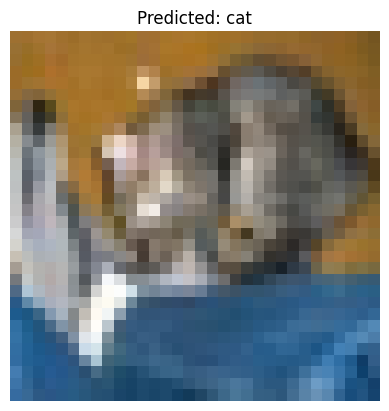

In [23]:
plt.imshow(x_test[0])

plt.title(f"Predicted: {predicted_class}")

plt.axis('off')

plt.show()

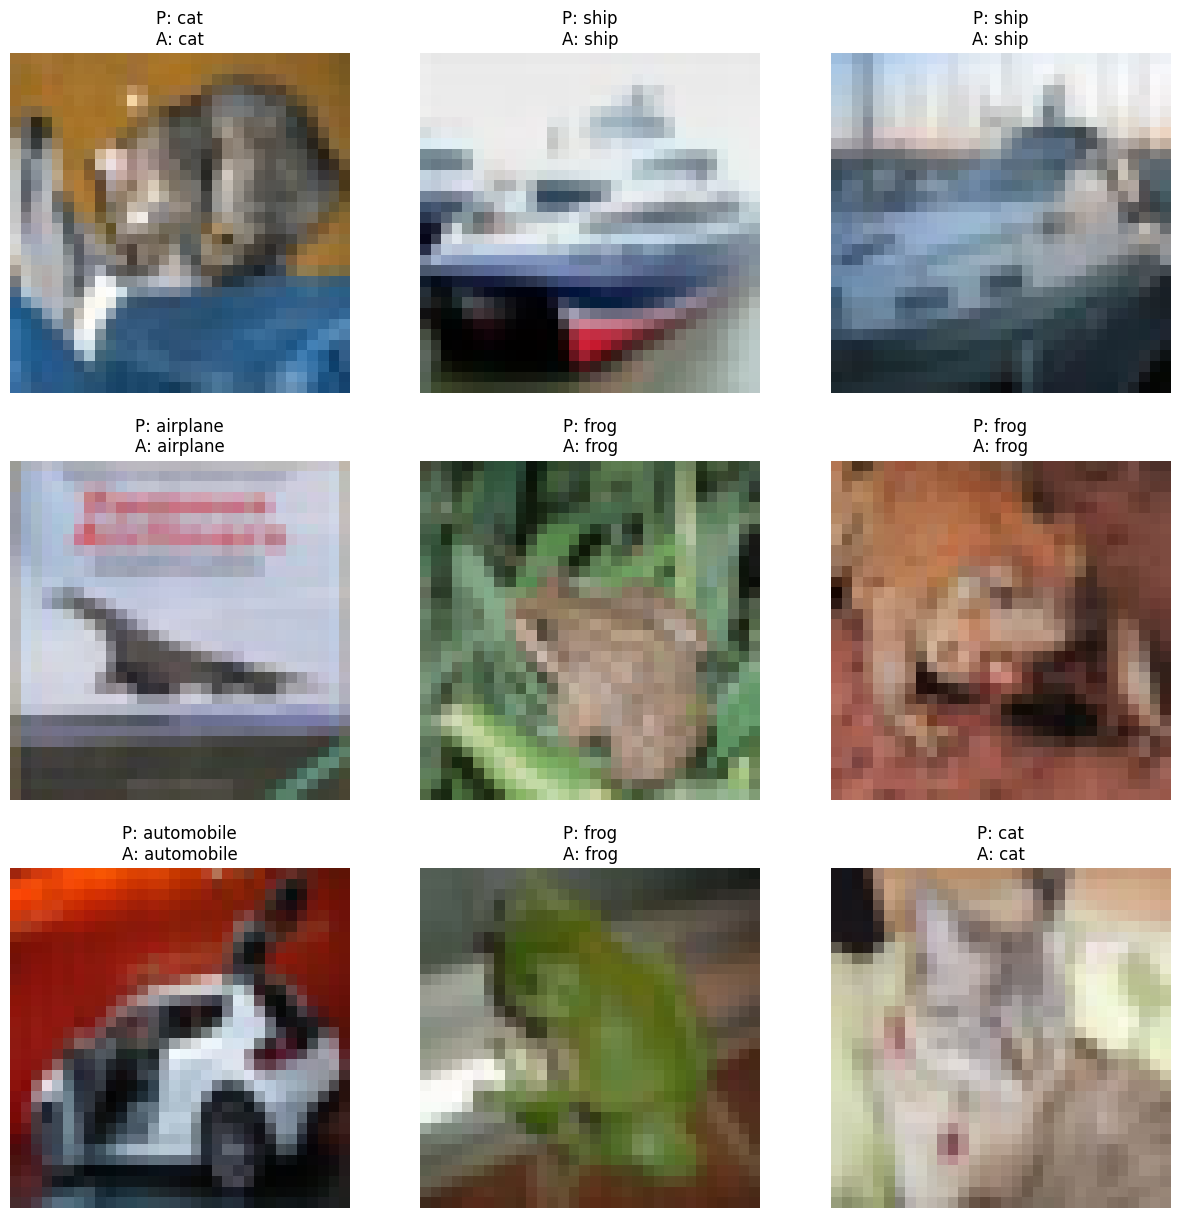

In [24]:
#to test multiple images
plt.figure(figsize=(15,15))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[i])

    predicted = class_names[prediction[i].argmax()]
    actual = class_names[y_test[i][0]]

    plt.title(f"P: {predicted}\nA: {actual}")

    plt.axis('off')

plt.show()

In [25]:
confidence = prediction[0].max()

print("Confidence:", confidence)

Confidence: 0.8637579


In [26]:
#let's improve the cnn model
#pr-1 is overfitting can be solved by dropout layer
from tensorflow.keras.layers import Dropout


In [28]:
#adding one more convolution layer, more filters
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
#training improved Model
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.3818 - loss: 1.6803 - val_accuracy: 0.5159 - val_loss: 1.3363
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.5291 - loss: 1.3203 - val_accuracy: 0.6005 - val_loss: 1.1296
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.5929 - loss: 1.1523 - val_accuracy: 0.6266 - val_loss: 1.0611
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.6361 - loss: 1.0446 - val_accuracy: 0.6320 - val_loss: 1.0578
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6641 - loss: 0.9685 - val_accuracy: 0.6632 - val_loss: 0.9732
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - accuracy: 0.6838 - loss: 0.9035 - val_accuracy: 0.6879 - val_loss: 0.9059
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.7067 - loss: 0.8466 - val_accuracy: 0.6945 - val_loss: 0.8901
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 50ms/step - accuracy: 0.7220 -

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [33]:
#AugmentationGenerator
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

In [34]:
datagen.fit(x_train)

In [35]:
history = model.fit(

    datagen.flow(x_train, y_train, batch_size=32),

    epochs=15,

    validation_data=(x_test, y_test)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.6504 - loss: 1.0188 - val_accuracy: 0.7043 - val_loss: 0.8725
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 102s 66ms/step - accuracy: 0.6673 - loss: 0.9826 - val_accuracy: 0.6790 - val_loss: 0.9623
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 0.6769 - loss: 0.9520 - val_accuracy: 0.7237 - val_loss: 0.8081
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 105s 67ms/step - accuracy: 0.6831 - loss: 0.9321 - val_accuracy: 0.7194 - val_loss: 0.8207
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 0.6873 - loss: 0.9158 - val_accuracy: 0.7240 - val_loss: 0.8326
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 0.6921 - loss: 0.9085 - val_accuracy: 0.7132 - val_loss: 0.8476
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 0.6947 - loss: 0.8914 - val_accuracy: 0.7396 - val_loss: 0.7698
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 104s 67ms/step - accuracy: 

In [36]:
model.save("cnn_image_classifier.h5")

In [37]:
from tensorflow.keras.models import load_model

loaded_model = load_model("cnn_image_classifier.h5")

In [38]:
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.save("cnn_image_classifier.keras")

In [40]:
loaded_model = load_model("cnn_image_classifier.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Now we will upload an external image, resize the image correctly, preprocess image, converting image into CNN fromat, making prediction based on, displaying confidence.


In [41]:
from google.colab import files

uploaded = files.upload()

Saving frog.jpg to frog.jpg


In [42]:
from tensorflow.keras.preprocessing import image
import numpy as np

In [43]:
img = image.load_img(
    'frog.jpg',
    target_size=(32,32)
)

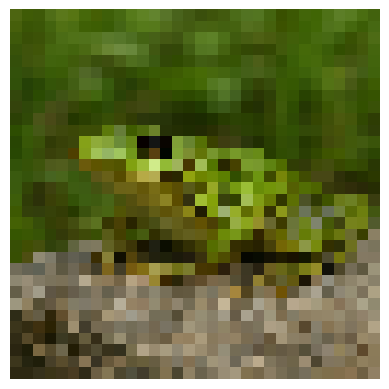

In [44]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [45]:
img_array = image.img_to_array(img)

print(img_array.shape)

(32, 32, 3)


In [46]:
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 32, 32, 3)


In [47]:
img_array = img_array / 255.0

In [48]:
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


In [49]:
predicted_index = prediction.argmax()

predicted_class = class_names[predicted_index]

print("Prediction:", predicted_class)

Prediction: frog


In [50]:
confidence = prediction.max() * 100

print(f"Confidence: {confidence:.2f}%")

Confidence: 97.33%


Converting this model to a better professional deep learning project using the concept of Tansfer learning: instead of trainig from zero, we use powerful pretrained models alredy trained on millions of data.

we work on using the best beginner transfer learning model: MobileNetV2


In [51]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [52]:
#loading pretrained base model
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(32,32,3)
)

/tmp/ipykernel_5480/3007263001.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [53]:
base_model.trainable = False

In [54]:
#Building transfer learning model
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [55]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [56]:
#training transfer learning model
history = model.fit(

    x_train,
    y_train,

    epochs=10,

    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 45ms/step - accuracy: 0.3013 - loss: 1.9293 - val_accuracy: 0.3282 - val_loss: 1.8632
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.3361 - loss: 1.8282 - val_accuracy: 0.3320 - val_loss: 1.8332
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.3490 - loss: 1.7896 - val_accuracy: 0.3488 - val_loss: 1.8123
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.3589 - loss: 1.7615 - val_accuracy: 0.3524 - val_loss: 1.8023
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.3682 - loss: 1.7387 - val_accuracy: 0.3527 - val_loss: 1.7974
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.3747 - loss: 1.7192 - val_accuracy: 0.3555 - val_loss: 1.7960
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.3784 - loss: 1.7031 - val_accuracy: 0.3579 - val_loss: 1.7911
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.3878 -

In [57]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.3532 - loss: 1.7947
Accuracy: 0.3531999886035919


In [58]:
import tensorflow as tf

# Resize training images
x_train_resized = tf.image.resize(x_train, (96, 96))

# Resize testing images
x_test_resized = tf.image.resize(x_test, (96, 96))

In [59]:
print(x_train_resized.shape)

(50000, 96, 96, 3)


In [60]:
#reloading mobilenetv2 inorder to increase accuracy
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [61]:
base_model.trainable = False

In [62]:
#building the latest improved model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [66]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [67]:
history = model.fit(

    x_train_resized,
    y_train,

    epochs=5,

    validation_data=(x_test_resized, y_test)
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 397s 250ms/step - accuracy: 0.8142 - loss: 0.5277 - val_accuracy: 0.8029 - val_loss: 0.5578
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 440s 249ms/step - accuracy: 0.8342 - loss: 0.4709 - val_accuracy: 0.7960 - val_loss: 0.5963
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 458s 259ms/step - accuracy: 0.8479 - loss: 0.4262 - val_accuracy: 0.7957 - val_loss: 0.5904
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 386s 247ms/step - accuracy: 0.8616 - loss: 0.3847 - val_accuracy: 0.8075 - val_loss: 0.5901
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 389s 249ms/step - accuracy: 0.8741 - loss: 0.3503 - val_accuracy: 0.8087 - val_loss: 0.6103


In [68]:
#saving the model
model.save("final_image_classifier.keras")

In [69]:
import os

print(os.listdir())

['.config', 'final_image_classifier.keras', 'frog.jpg', 'cnn_image_classifier.keras', 'cnn_image_classifier.h5', 'sample_data']


In [70]:
#loading saved model
from tensorflow.keras.models import load_model

loaded_model = load_model("final_image_classifier.keras")

In [71]:
loaded_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753,760 (10.50 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,518 (1.26 MB)

In [72]:
#testing the accuarcy of the loaded model
test_loss, test_accuracy = loaded_model.evaluate(
    x_test_resized,
    y_test
)

print("Loaded Model Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 207ms/step - accuracy: 0.8087 - loss: 0.6103
Loaded Model Accuracy: 0.8087000250816345


In [73]:
#predicting using load model
prediction = loaded_model.predict(x_test_resized[:1])

predicted_index = prediction.argmax()

print("Predicted Class:", class_names[predicted_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: cat
